# Learning to Play Snake with Reinforcement Learning

**Problem Statement:** Reinforcement Learning (RL) trains an agent to make decisions by interacting with an environment to maximize rewards. In this project, we apply RL to Snake.



## 1. Install and Import Dependencies

In [44]:
import sys
print(sys.executable)
print(sys.version)

#comment out when finish download
# !{sys.executable} -m pip install -U matplotlib seaborn tqdm
# !{sys.executable} -m pip install -U gymnasium matplotlib seaborn tqdm torch
# !{sys.executable} -m pip install -U pygame
# !{sys.executable} -m pip install -U pandas

/usr/local/bin/python3.13
3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]


In [45]:

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

## 2. Set Up the Snake Environment

The Snake-v1 environment simulates the classic grid-based Snake game with the following:
- **State**: A feature vector describing the snake’s immediate situation (compact, learnable representation).
  - `danger_straight` (0/1): (0/1): Collision if the snake continues forward

  - `danger_left` (0/1): Collision if the snake turns left

  - `danger_right` (0/1): Collision if the snake turns right

  - `food_left` (0/1): Food is to the left of the head

  - `food_right` (0/1): Food is to the right of the head

  - `food_up` (0/1): Food is above the head
  
  - `food_down` (0/1): Food is below the head

  - `moving_left` (0/1): Snake is currently moving left

  - `moving_right` (0/1): Snake is currently moving right

  - `moving_up` (0/1): Snake is currently moving up
  
  - `moving_down` (0/1): Snake is currently moving down
  
- **Actions**: 0 = Straight 1 = Turn Left 2 = Turn Right 
- **Rewards**: +10 when snake eats food, -10 when the snake dies, -0.1 each step taken 
- **done condition**: snake collides with a wall, with its own body, max limit reached


### 2a. Snake Environment Code Explantation
- The __init__() method initializes the enviroment by defining: 
    - the grid size

    - the maximum number of steps allowed for each episode 

    - observations of space and action used by the agent
- __reset__() function starts by: 
    - resetting the step counter 

    - placing the snake at the center of the grid 

    - spawning new pieces of food at a random location 

- __step(action)__ updates the enviroment each time the agent takes an action:
    - updates the snake direction, based on the action 

    - moves the snake head position 

    - checks for collision of self or wall 

    - determines if the food is eaten 
    
    - return observations, rewards, and termination signals. 
- __spawn_food()__:
    - helps the function randomly placing food on the grid, making sure it doesn't spawn in the snake body
- __turn()__:
    - function converts actions into the updated movement direction
- __danger()__:
    - function checks whether the action results into a collision
- __get_obs()__:
    - creates featured vector describing the snake current situation, returning to the learning agent



In [46]:

class SnakeEnv(gym.Env):
    """
    Minimal Snake environment (work-in-progress).
    Actions: 0=Straight, 1=Left, 2=Right
    Observation: 11-dim feature vector
    """

    REWARD_EAT = 10.0
    PENALTY_DEATH = -10.0
    STEP_PENALTY = -0.1

    def __init__(self, grid_size=10, max_steps=500):
        super().__init__()
        self.grid_size = grid_size
        self.max_steps = max_steps

        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(11,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        mid = self.grid_size // 2
        self.direction = (1, 0)  # right
        self.snake = [(mid, mid), (mid - 1, mid), (mid - 2, mid)]
        self._spawn_food()

        obs = self._get_obs()
        info = {}
        return obs, info

    def step(self, action):
        self.steps += 1
       
        self.direction = self._turn(self.direction, action)

        head_x, head_y = self.snake[0]
        dx, dy = self.direction
        new_head = (head_x + dx, head_y + dy)

        reward = self.STEP_PENALTY
        terminated = False
        truncated = False

        # Collision with wall
        if not (0 <= new_head[0] < self.grid_size and 0 <= new_head[1] < self.grid_size):
            reward = self.PENALTY_DEATH
            terminated = True

        # Collision with self
        elif new_head in self.snake:
            reward = self.PENALTY_DEATH
            terminated = True

        else:
            # Advance snake
            self.snake.insert(0, new_head)

            # Eat food
            if new_head == self.food:
                reward = self.REWARD_EAT
                self._spawn_food()
            else:
                self.snake.pop()  

        if self.steps >= self.max_steps:
            truncated = True

        obs = self._get_obs()
        info = {"length": len(self.snake)}
        return obs, reward, terminated, truncated, info

    def _spawn_food(self):
        while True:
            fx = self.np_random.integers(0, self.grid_size)
            fy = self.np_random.integers(0, self.grid_size)
            if (fx, fy) not in self.snake:
                self.food = (fx, fy)
                return

    def _turn(self, direction, action):
        dx, dy = direction
        if action == 0:      # straight
            return (dx, dy)
        if action == 1:      # left
            return (-dy, dx)
        else:                # right
            return (dy, -dx)

    def _danger(self, direction):
        head_x, head_y = self.snake[0]
        dx, dy = direction
        nxt = (head_x + dx, head_y + dy)
        if not (0 <= nxt[0] < self.grid_size and 0 <= nxt[1] < self.grid_size):
            return 1.0
        if nxt in self.snake:
            return 1.0
        return 0.0

    def _get_obs(self):
        head_x, head_y = self.snake[0]
        fx, fy = self.food
        dx, dy = self.direction

        straight = (dx, dy)
        left = (-dy, dx)
        right = (dy, -dx)

        danger_straight = self._danger(straight)
        danger_left = self._danger(left)
        danger_right = self._danger(right)

        food_left = 1.0 if fx < head_x else 0.0
        food_right = 1.0 if fx > head_x else 0.0
        food_up = 1.0 if fy < head_y else 0.0
        food_down = 1.0 if fy > head_y else 0.0

        moving_left = 1.0 if (dx, dy) == (-1, 0) else 0.0
        moving_right = 1.0 if (dx, dy) == (1, 0) else 0.0
        moving_up = 1.0 if (dx, dy) == (0, -1) else 0.0
        moving_down = 1.0 if (dx, dy) == (0, 1) else 0.0

        return np.array([
            danger_straight, danger_left, danger_right,
            food_left, food_right, food_up, food_down,
            moving_left, moving_right, moving_up, moving_down
            ], dtype=np.float32)


In [47]:

env = SnakeEnv()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print("Actions: 0=Straight, 1=Turn Left, 2=Turn Right")

Observation space: Box(0.0, 1.0, (11,), float32)
Action space: Discrete(3)
Actions: 0=Straight, 1=Turn Left, 2=Turn Right


### 2b. random episodes to understand the enviornment
- we run a small set of sample episodes to manually understand the behavior of the environment 

- for each sample run, its output is organized step by step and prints: 
    - the next state 

    - the reward received 

    - whether if the episode has terminated
    
    - current snake length

- at the end of each episodes, the program prints the final snake length and the amount steps taken before being terminated 

In [48]:

print("=== Sample Episodes ===")

for episode in range(3):

    state, info = env.reset()
    print(f"\nEpisode {episode + 1}")
    print(f"Initial state: {state}")

    done = False
    step = 0

    while not done:

        # Random action
        action = env.action_space.sample()

        if action == 0:
            action_name = "Straight"
        elif action == 1:
            action_name = "Turn Left"
        else:
            action_name = "Turn Right"

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        step += 1

        print(
            f"Step {step}: "
            f"Action={action_name}, "
            f"Reward={reward}, "
            f"Length={info['length']}"
        )

        state = next_state

    print(f"Episode finished after {step} steps. Final length: {info['length']}")

=== Sample Episodes ===

Episode 1
Initial state: [0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0.]
Step 1: Action=Turn Right, Reward=-0.1, Length=3
Step 2: Action=Turn Right, Reward=-0.1, Length=3
Step 3: Action=Straight, Reward=-0.1, Length=3
Step 4: Action=Turn Right, Reward=-0.1, Length=3
Step 5: Action=Straight, Reward=-0.1, Length=3
Step 6: Action=Turn Right, Reward=-0.1, Length=3
Step 7: Action=Turn Right, Reward=-0.1, Length=3
Step 8: Action=Straight, Reward=-0.1, Length=3
Step 9: Action=Turn Left, Reward=-0.1, Length=3
Step 10: Action=Turn Right, Reward=-0.1, Length=3
Step 11: Action=Straight, Reward=-0.1, Length=3
Step 12: Action=Turn Right, Reward=-0.1, Length=3
Step 13: Action=Turn Right, Reward=-0.1, Length=3
Step 14: Action=Turn Right, Reward=-0.1, Length=3
Step 15: Action=Straight, Reward=-0.1, Length=3
Step 16: Action=Turn Left, Reward=-0.1, Length=3
Step 17: Action=Turn Left, Reward=-0.1, Length=3
Step 18: Action=Turn Right, Reward=-0.1, Length=3
Step 19: Action=Turn Left, Reward=-0.

## 3. Random Policy Baseline (Snake)

We've provided two baselines:

1. Random policy agent: This agent selects a action uniformly at random at every step.
    - actions: straight, turn left, turn right 

2. greedy: it always tries to reduce distance to the food __NO MATTER WHAT__, even if that risks dying

Our Goal: to outperform these baselines on average on scores and survival time

In [49]:

def evaluate_policy(env, policy_fn, n_episodes=2000):

    """
    Evaluate a Snake policy over many episodes.

    Args:
        env: SnakeEnv
        policy_fn: function(state) -> action
        n_episodes: number of episodes to simulate

    Returns:
        Dictionary of evaluation metrics.
    """
    scores = []
    steps_list = []
    total_rewards = []
    deaths = 0

    for _ in range(n_episodes):
        state, info = env.reset()
        done = False
        steps = 0
        ep_reward = 0.0

        start_len = info.get("length", 3)

        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            ep_reward += reward
            steps += 1

            if terminated:
                deaths += 1

        final_len = info.get("length", start_len)
        score = final_len - start_len  # foods eaten ≈ length increase

        scores.append(score)
        steps_list.append(steps)
        total_rewards.append(ep_reward)

    return {
        "avg_score": float(np.mean(scores)),
        "median_score": float(np.median(scores)),
        "avg_steps": float(np.mean(steps_list)),
        "death_rate": float(deaths / n_episodes),
        "avg_total_reward": float(np.mean(total_rewards))
    }

### 3a. Random Policy + Greedy Policy
- We evaluate both policies over many episodes using average score, average steps, and death rate.

In [50]:
def greedy_to_food_action(state):
    food_left  = state[3] == 1.0
    food_right = state[4] == 1.0
    food_up    = state[5] == 1.0
    food_down  = state[6] == 1.0

    moving_left  = state[7] == 1.0
    moving_right = state[8] == 1.0
    moving_up    = state[9] == 1.0
    moving_down  = state[10] == 1.0


    if food_left:
        target = "LEFT"
    elif food_right:
        target = "RIGHT"
    elif food_up:
        target = "UP"
    elif food_down:
        target = "DOWN"
    else:
        return 0  # straight

    if moving_right:
        if target == "RIGHT": return 0
        if target == "UP":    return 1
        if target == "DOWN":  return 2
        if target == "LEFT":  return 1
    elif moving_left:
        if target == "LEFT":  return 0
        if target == "DOWN":  return 1
        if target == "UP":    return 2
        if target == "RIGHT": return 1
    elif moving_up:
        if target == "UP":    return 0
        if target == "LEFT":  return 1
        if target == "RIGHT": return 2
        if target == "DOWN":  return 1
    elif moving_down:
        if target == "DOWN":  return 0
        if target == "RIGHT": return 1
        if target == "LEFT":  return 2
        if target == "UP":    return 1

    return 0


random_policy = lambda state: env.action_space.sample()

metrics = evaluate_policy(env, random_policy, n_episodes=2000)
print("Random Policy:")
print(f"  Avg score: {metrics['avg_score']:.3f}")
print(f"  Median score: {metrics['median_score']:.3f}")
print(f"  Avg steps: {metrics['avg_steps']:.1f}")
print(f"  Death rate: {metrics['death_rate']:.3%}")

metrics = evaluate_policy(env, greedy_to_food_action, n_episodes=2000)

print("Greedy-to-Food Policy (ignores danger):")
print(f"  Avg score: {metrics['avg_score']:.3f}")
print(f"  Median score: {metrics['median_score']:.3f}")
print(f"  Avg steps: {metrics['avg_steps']:.1f}")
print(f"  Death rate: {metrics['death_rate']:.3%}")
print(f"  Avg total reward: {metrics['avg_total_reward']:.3f}")


Random Policy:
  Avg score: 0.157
  Median score: 0.000
  Avg steps: 19.0
  Death rate: 100.000%
Greedy-to-Food Policy (ignores danger):
  Avg score: 0.041
  Median score: 0.000
  Avg steps: 10.6
  Death rate: 100.000%
  Avg total reward: -10.552


### 3b. Graphing of Random + Greedy Baselines 
- the table records two main metrics for comparsion: 
    - average score 
    - average steps taken


   Policy  Avg Score  Avg Steps
0  Random      0.159    18.9005
1  Greedy      0.042    10.5745


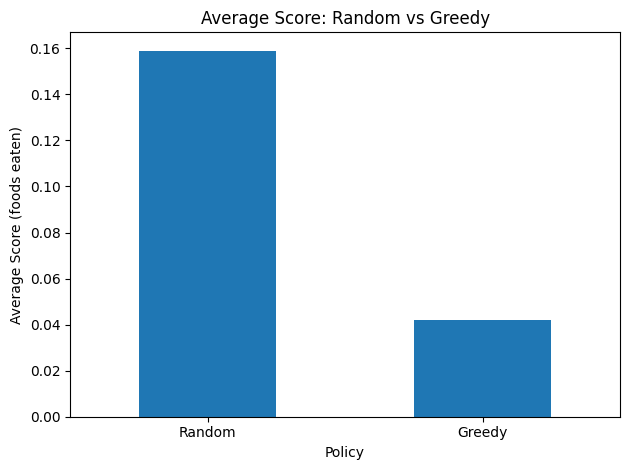

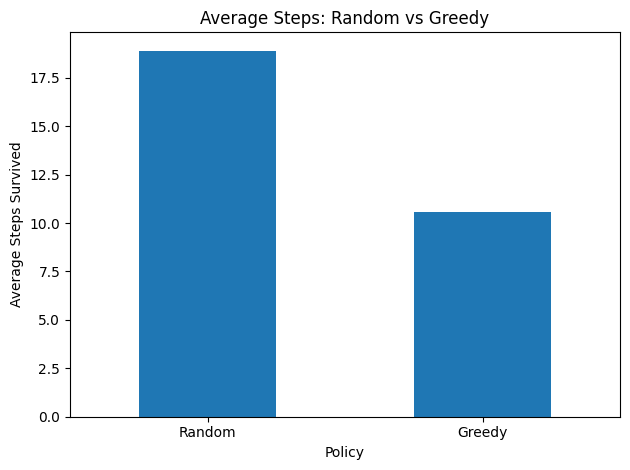

In [51]:

random_metrics = evaluate_policy(env, lambda s: env.action_space.sample(), n_episodes=2000)
greedy_metrics = evaluate_policy(env, greedy_to_food_action, n_episodes=2000)


df = pd.DataFrame([
    {"Policy": "Random", "Avg Score": random_metrics["avg_score"], "Avg Steps": random_metrics["avg_steps"]},
    {"Policy": "Greedy", "Avg Score": greedy_metrics["avg_score"], "Avg Steps": greedy_metrics["avg_steps"]},
])

print(df)

# bar graph for score
ax = df.plot(x="Policy", y="Avg Score", kind="bar", legend=False)
ax.set_title("Average Score: Random vs Greedy")
ax.set_ylabel("Average Score (foods eaten)")
ax.set_xlabel("Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# bar graph for steps 
ax = df.plot(x="Policy", y="Avg Steps", kind="bar", legend=False)
ax.set_title("Average Steps: Random vs Greedy")
ax.set_ylabel("Average Steps Survived")
ax.set_xlabel("Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Training
-   we first train a tabular Q-learning agent to establish a reinforcement learning baseline

- the agent learns from an epilson-greedy policy

- after establishing tabular learning baseline, we plan to extend the apporach to a __DQN__

### 4a. Tabular reinforcement learning agent


In [ ]:
class QLearningAgent:
    def __init__(self, action_space_n, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        self.action_space_n = action_space_n
        self.alpha = alpha
        self.gamma = gamma

        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        self.Q = {}  

    def _key(self, state):
      
        return tuple(int(x > 0.5) for x in state)

    def _ensure_state(self, s_key):
        if s_key not in self.Q:
            self.Q[s_key] = np.zeros(self.action_space_n, dtype=np.float32)
    
    def act(self, state):
       
        s_key = self._key(state)
        self._ensure_state(s_key)

        if random.random() < self.epsilon:
            return random.randrange(self.action_space_n)
        return int(np.argmax(self.Q[s_key]))

    def learn(self, state, action, reward, next_state, done):
        
        s_key = self._key(state)
        ns_key = self._key(next_state)
        self._ensure_state(s_key)
        self._ensure_state(ns_key)

        q_sa = self.Q[s_key][action]
        target = reward if done else reward + self.gamma * np.max(self.Q[ns_key])
        self.Q[s_key][action] += self.alpha * (target - q_sa)

    def end_episode(self):
       
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


In [63]:
def train_q_learning(env, agent, n_episodes=2000):
    scores = []
    steps_list = []
    rewards = []

    for _ in range(n_episodes):
        state, info = env.reset()
        done = False
        total_reward = 0
        steps = 0
        start_len = info.get("length", 3)

        while not done:
            action = agent.act(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.learn(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            steps += 1

        agent.end_episode()

        final_len = info.get("length", start_len)
        score = final_len - start_len

        scores.append(score)
        steps_list.append(steps)
        rewards.append(total_reward)
    return scores, steps_list, rewards

### 4b. visualization of tabular q learning vs random and greedy baselines 


                 Policy  Avg Score  Avg Steps
0                Random     0.1725     19.383
1                Greedy     0.0390     10.719
2  Q-Learning (trained)    16.0335    149.099


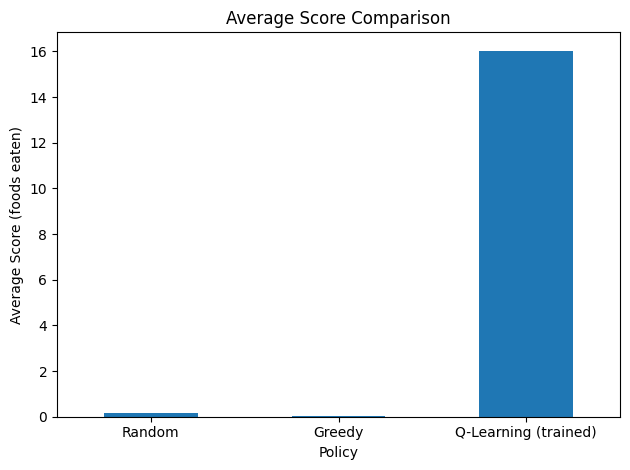

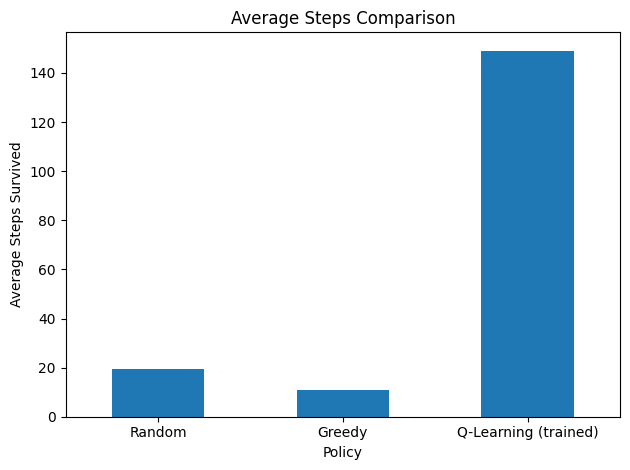

In [ ]:

random_policy = lambda s: env.action_space.sample()
greedy_policy = greedy_to_food_action

agent = QLearningAgent(
    action_space_n=env.action_space.n,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05
)


scores, steps, rewards = train_q_learning(env, agent, n_episodes=2000)

# use "greedy" when epsilon is at 0.0
old_eps = agent.epsilon
agent.epsilon = 0.0
trained_policy = lambda s: agent.act(s)

rand_metrics = evaluate_policy(env, random_policy, n_episodes=2000)
greedy_metrics = evaluate_policy(env, greedy_policy, n_episodes=2000)
train_metrics = evaluate_policy(env, trained_policy, n_episodes=2000)

agent.epsilon = old_eps  

df = pd.DataFrame([
    {"Policy": "Random", "Avg Score": rand_metrics["avg_score"], "Avg Steps": rand_metrics["avg_steps"]},
    {"Policy": "Greedy", "Avg Score": greedy_metrics["avg_score"], "Avg Steps": greedy_metrics["avg_steps"]},
    {"Policy": "Q-Learning (trained)", "Avg Score": train_metrics["avg_score"], "Avg Steps": train_metrics["avg_steps"]},
])

print(df)


ax = df.plot(x="Policy", y="Avg Score", kind="bar", legend=False)
ax.set_title("Average Score Comparison")
ax.set_ylabel("Average Score (foods eaten)")
ax.set_xlabel("Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



ax = df.plot(x="Policy", y="Avg Steps", kind="bar", legend=False)
ax.set_title("Average Steps Comparison")
ax.set_ylabel("Average Steps Survived")
ax.set_xlabel("Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Summary and Analysis of Results

To start our project, we set up some code define the snake board environment, and the learning reward policy - basic infrastructure that we'll need to train our model. Then we defined some baselines that we'll compare our final model to. These being the random baseline and the greedy policy. As proof of concept we trained a simple tabular Q-learning algorithm (with no neural network) and compared it to our first two baselines. As can be seen from the results above it far outperformed them, earning an average score of approximately 16 versus about 0.04 for greedy and 0.2 for random. Q-Learning survived about 150 steps on average while greedy survived just 11 steps approximately and random just 19 approximately on average. This was done on a small grid of 10x10 with no obstacles. Next, we'll use similar logic to train a Deep Q Network to play the game extremely well on larger boards and those with obstacles. The goal is to beat all of these baselines on varying board sizes and ideally, to beat the game.